In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

from tensorflow.keras.datasets import fashion_mnist

In [2]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)

(60000, 28, 28)


In [3]:
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

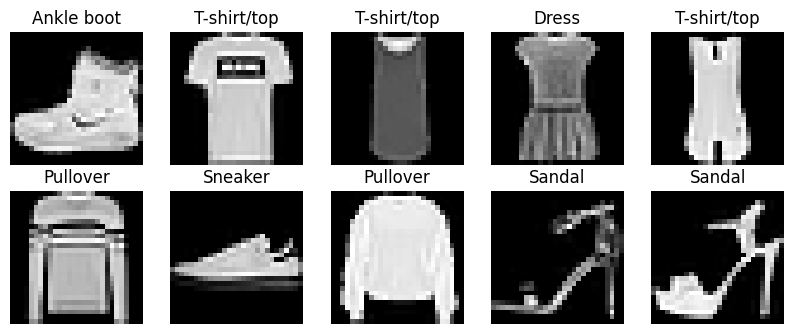

In [4]:
plt.figure(figsize=(10,10))

for i in range(10):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(labels[y_train[i]])
    plt.axis('off')

plt.show()

In [5]:
X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0

In [6]:
import numpy as np

def one_hot(y, num_classes=10):
    one_hot_y = np.zeros((y.size, num_classes))
    one_hot_y[np.arange(y.size), y] = 1
    return one_hot_y

y_train_encoded = one_hot(y_train)
y_test_encoded = one_hot(y_test)

print(y_train_encoded.shape)

(60000, 10)


In [7]:
def forward(X):
    global Z1, A1, Z2, A2

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return A2

In [8]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [9]:
def cross_entropy(y_true, y_pred):
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

In [10]:
input_size = 784
hidden_size = 128
output_size = 10

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
b2 = np.zeros((1, output_size))

In [11]:
def backward(X, y_true, learning_rate):

    global W1, b1, W2, b2

    m = X.shape[0]

    # Output layer gradient
    dZ2 = A2 - y_true

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradient
    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * (Z1 > 0)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Update weights
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [12]:
def accuracy(y_true, y_pred):
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    return np.mean(y_true_labels == y_pred_labels)

In [13]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [ ]:
import wandb

In [14]:
epochs = 20
learning_rate = 0.001
batch_size = 64

for epoch in range(epochs):

    indices = np.random.permutation(X_train.shape[0])

    X_shuffled = X_train[indices]
    y_shuffled = y_train_encoded[indices]

    for i in range(0, X_train.shape[0], batch_size):

        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        predictions = forward(X_batch)

        loss = cross_entropy(y_batch, predictions)

        wandb.log({
            "loss": loss
        })

        backward(X_batch, y_batch, learning_rate)

    train_predictions = forward(X_train)

    train_acc = accuracy(y_train_encoded, train_predictions)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {train_acc:.4f}")

Error: You must call wandb.init() before wandb.log()

In [ ]:
test_predictions = forward(X_test)

test_acc = accuracy(y_test_encoded, test_predictions)

print("Test Accuracy:", test_acc)

In [ ]:
predicted_labels = np.argmax(test_predictions, axis=1)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    true_label = labels[y_test[i]]
    pred_label = labels[predicted_labels[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.show()

In [ ]:
wandb.init(project="fashion-mnist-numpy-nn")

In [ ]:
def accuracy(y_true, y_pred):
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    return np.mean(y_true_labels == y_pred_labels)